In [110]:
from mGST.utility_functions_comparisons import get_compressed_rep_from_mgst_output, run_gds_jax
from mGST.low_level_jit import cost_function_jax_mps, cost_function_numba, cost_function_jax
from mGST.algorithm import run_mGST

from mGST.additional_fns import perturbed_target_init

from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np


backend = "iqmfakeapollo"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2Q Emerald

## Setup

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import CZGate, RGate
import pickle

qubit_layouts = [[2,8], [4,10], [6,12], [15,23], [19,25], [21,27], [31,39], [30,35], [42,46], [44,48]]

gates = [QuantumCircuit(2, 0) for _ in range(7)]
gates[0].append(RGate(1e-9, 0), [0])
gates[1].append(RGate(0.5 * jnp.pi, 0), [0])
gates[2].append(RGate(0.5 * jnp.pi, 0), [1])
gates[3].append(RGate(0.5 * jnp.pi, jnp.pi / 2), [0])
gates[4].append(RGate(0.5 * jnp.pi, jnp.pi / 2), [1])
gates[5].append(RGate(0.5 * jnp.pi, 0), [0])
gates[5].append(RGate(0.5 * jnp.pi, 0), [1])
gates[6].append(CZGate(), [[0], [1]])
gate_labels = [
    "Idle",
    "Rx(pi/2):0",
    "Rx(pi/2):1",
    "Ry(pi/2):0",
    "Ry(pi/2):1",
    "Rx(pi/2)-Rx(pi/2):0-1",
    "CZ",
]

Q2_GST_EMERALD = GSTConfiguration(
    qubit_layouts=qubit_layouts,
    gate_set=gates,
    gate_labels = gate_labels,
    num_circuits=1000,
    shots=1000,
    rank=16,
    opt_method="GD",
    max_iterations = [140, 250],
    convergence_criteria=[4, 1e-4],
    parallel_execution = True,
    max_gates_per_batch = 35000
)

with open('emerald_2q_parallel_qubits_44__48.pkl', 'rb') as f:
    data = pickle.load(f)
    
X_true = data["X_true"]
E_true = data["E_true"]
rho_true = data["rho_true"]

K_target = data["K_target"]
X_target = data["X_target"]
E_target = data["E_target"]
rho_target = data["rho_target"]

# dimensions
dim = rho_true.shape[0]
num_povm = E_true.shape[0]
num_gates = X_true.shape[0]
bsize = 30 * dim
# Getting the values to be initialized
kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target = get_compressed_rep_from_mgst_output(X_target, E_target, rho_target, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax_target = povm_psd_2q_target.conj().transpose(0, 2, 1) @ povm_psd_2q_target
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_target, kraus_tensor_2q_target.conj()).reshape((num_gates, dim**2, dim**2))

rho_target_matrix = rho_target.reshape(dim, dim)
povm_target_matrices = E_target.reshape(num_povm, dim, dim)

jnp.allclose(state_psd_2q_target @ state_psd_2q_target.conj().T, rho_target_matrix), jnp.allclose(povm_jax_target, povm_target_matrices), jnp.allclose(superop_kraus_test, X_target)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [11]:
state_mgst_true = rho_true.reshape(-1)
povm_mgst_true = E_true.reshape(num_povm, -1)

kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true  = get_compressed_rep_from_mgst_output(X_true, povm_mgst_true, state_mgst_true, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax = povm_psd_2q_true.conj().transpose(0, 2, 1) @ povm_psd_2q_true
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_true, kraus_tensor_2q_true.conj()).reshape((num_gates, dim**2, dim**2))

target_operators = [kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target]

jnp.allclose(state_psd_2q_true @ state_psd_2q_true.conj().T, rho_true), jnp.allclose(povm_jax, E_true), jnp.allclose(superop_kraus_test, X_true)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [7]:
from mGST.additional_fns import sampled_measurements, random_seq_design
from mGST.low_level_jit import contract_mps_all_povm

shots = 1000

N = 100  # Number of sequences
N_short = int(jnp.ceil(N / 2))
N_long = int(jnp.floor(N / 2))
meas_samples = 1e5  # Number of samples per sequences

# generate random numbers between 0 and $d^l - 1$
J = random_seq_design(num_gates, 1, 8, 14, N_short, N_long)
indices_list_2q = [indices[indices != -1] for indices in J]
# compute outcome probabilities
prob_matrix_exact = []
for indices in indices_list_2q:
    prob_matrix_exact.append(jnp.real(contract_mps_all_povm(kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true, indices)))
    
prob_matrix_exact = jnp.array(prob_matrix_exact).T
prob_matrix_2q_sampled = sampled_measurements(prob_matrix_exact, shots, seed=42)


In [15]:
kraus_rank = dim**2
K_init_mgst = perturbed_target_init(X_target, kraus_rank, seed=42)
X_init_mgst = jnp.einsum("ijkl,ijnm -> iknlm", K_init_mgst, K_init_mgst.conj()).reshape((num_gates, dim**2, dim**2))
E_target_mgst = E_target.reshape(num_povm, -1)
rho_target_mgst = rho_target.reshape(-1)
init_mgst = [K_init_mgst, E_target_mgst, rho_target_mgst]

kraus_tensor_2q_init = jnp.array(K_init_mgst)

## Testing Hessian performance

### State

In [21]:
cost_value_init = cost_function_jax_mps(kraus_tensor_2q_init, povm_psd_2q_target, state_psd_2q_target, indices_list_2q, prob_matrix_2q_sampled, jit=True)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3
at iteration 13 the new count changed to: 4
at iteration 19 the new count changed to: 5
at iteration 25 the new count changed to: 6
at iteration 31 the new count changed to: 7
at iteration 37 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15


In [23]:
# timing test for the hessian on the state
from mGST.algorithm import B_SFN_riem_Hess

updated_state = B_SFN_riem_Hess(
    K=kraus_tensor_2q_init,
    A=povm_psd_2q_target,
    B=state_psd_2q_target,
    y=prob_matrix_2q_sampled,
    J=indices_list_2q,
    d=num_gates,
    r=dim**2,
    n_povm=num_povm,
    lam=1e-3
)

test_cost_value = cost_function_jax_mps(kraus_tensor_2q_init, povm_psd_2q_target, updated_state, indices_list_2q, prob_matrix_2q_sampled, jit=True)

test_cost_value, cost_value_init, test_cost_value < cost_value_init


(Array(0.0037082, dtype=float64),
 Array(0.00375904, dtype=float64),
 Array(True, dtype=bool))

In [19]:
%timeit B_SFN_riem_Hess(K=kraus_tensor_2q_init, A=povm_psd_2q_target, B=state_psd_2q_target, y=prob_matrix_2q_sampled, J=indices_list_2q, d=num_gates, r=dim**2, n_povm=num_povm, lam=1e-3)

243 ms ± 17 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### POVM

In [ ]:
from mGST.algorithm import A_SFN_riem_Hess

povm_test_np = np.array(povm_psd_2q_target)
state_test_np = np.array(state_psd_2q_target)

updated_povm = A_SFN_riem_Hess(
    K=kraus_tensor_2q_init,
    A=povm_test_np,
    B=state_test_np,
    y=prob_matrix_2q_sampled,
    J=indices_list_2q,
    d=num_gates,
    r=dim**2,
    n_povm=num_povm,
    lam=1e-3
)

cost_povm_updated = cost_function_jax_mps(kraus_tensor_2q_init, updated_povm, state_psd_2q_target, indices_list_2q, prob_matrix_2q_sampled, jit=True)

test_cost_value, cost_value_init, cost_povm_updated, type(updated_povm)

(Array(0.0037082, dtype=float64),
 Array(0.00375904, dtype=float64),
 Array(0.00340034, dtype=float64),
 numpy.ndarray)

In [66]:
%timeit A_SFN_riem_Hess(K=kraus_tensor_2q_init, A=povm_test_np, B=state_test_np, y=prob_matrix_2q_sampled, J=indices_list_2q,d=num_gates,r=dim**2,n_povm=num_povm,lam=1e-3)

747 ms ± 102 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## optimization

In [ ]:
kraus_updated_2q_mgst, x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, cost_fn_history_2q_mgst = run_mGST(
    prob_matrix_2q_sampled, indices_list_2q, 0, num_gates, dim**2, 16, num_povm, bsize, shots,
    init = init_mgst,
    method = "GD",
    max_iter=250,
    target_rel_prec=1e-4,
)

Starting mGST optimization...
100%|██████████| 70/70 [01:38<00:00,  1.40s/it]
	 Convergence criterion satisfied
	 Final objective 4.059975006904586e-05 in time 98.22s


In [101]:
kraus_updated_2q_all_gds, povm_updated_2q_all_gds, state_updated_2q_all_gds, cost_fn_history_2q_all_gds = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_init,
    povm_psd=povm_psd_2q_target,
    state_psd=state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8,
    ls_max_iter=30,
    regularized=False,
    return_operators_list=False,
    which_hessian=[])

iteration:  0
Using JAX power
Optimized step size for Povm: [29.00000001]
Using JAX power
Optimized step size for Kraus: [10.56738282]
Using JAX power
Optimized step size for State: [7.12739728]
cost:  0.003759040152925293
iteration:  1
Using JAX power
Optimized step size for Povm: [34.5364211]
Using JAX power
Optimized step size for Kraus: [27.95800782]
Using JAX power
Optimized step size for State: [5.79839571]
cost:  0.00282610772713545
iteration:  2
Using JAX power
Optimized step size for Povm: [24.95683126]
Using JAX power
Optimized step size for Kraus: [11.32519532]
Using JAX power
Optimized step size for State: [8.68125235]
cost:  0.0021276705668944735
iteration:  3
Using JAX power
Optimized step size for Povm: [27.71429962]
Using JAX power
Optimized step size for Kraus: [18.61405782]
Using JAX power
Optimized step size for State: [7.04609845]
cost:  0.0015476924805562558
iteration:  4
Using JAX power
Optimized step size for Povm: [27.01829884]
Using JAX power
Optimized step siz

In [94]:
# only the hessian on the state, no povm
kraus_updated_2q_unregularized_hessian_state, povm_updated_2q_unregularized_hessian_state, state_updated_2q_unregularized_hessian_state, cost_fn_history_2q_unregularized_hessian_state = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_init,
    povm_psd=povm_psd_2q_target,
    state_psd=state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8,
    ls_max_iter=30,
    use_hessian=True,
    regularized=False,
    return_operators_list=False,
    which_hessian=["state"])

iteration:  0
Using JAX power
Optimized step size for Povm: [29.00000001]
Using JAX power
Optimized step size for Kraus: [10.56738282]
cost:  0.003759040152925293
iteration:  1
Using JAX power
Optimized step size for Povm: [29.00000001]
Using JAX power
Optimized step size for Kraus: [23.81250001]
cost:  0.00282478992405807
iteration:  2
Using JAX power
Optimized step size for Povm: [25.00000001]
Using JAX power
Optimized step size for Kraus: [12.45751954]
cost:  0.002180353647391572
iteration:  3
Using JAX power
Optimized step size for Povm: [29.00000001]
Using JAX power
Optimized step size for Kraus: [16.73437501]
cost:  0.0016252203193696268
iteration:  4
Using JAX power
Optimized step size for Povm: [26.00000001]
Using JAX power
Optimized step size for Kraus: [11.96337892]
cost:  0.0012019756508726102
iteration:  5
Using JAX power
Optimized step size for Povm: [26.75000001]
Using JAX power
Optimized step size for Kraus: [16.76171876]
cost:  0.0009225037725395666
iteration:  6
Using 

In [90]:
# this is using the state AND povm's hessian
# Note: the mGST uses 200 line search iterations.
kraus_updated_2q_unregularized_hessian_povm, povm_updated_2q_unregularized_hessian_povm, state_updated_2q_unregularized_hessian_povm, cost_fn_history_2q_unregularized_hessian_povm = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_init,
    povm_psd=povm_psd_2q_target,
    state_psd=state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8,
    ls_max_iter=200, # the same as the value for the gradient descent in MGST
    use_hessian=True,
    regularized=False,
    return_operators_list=False)

iteration:  0
Using JAX power
Optimized step size for Kraus: [10.09336173]
cost:  0.003759040152925293
iteration:  1
Using JAX power
Optimized step size for Kraus: [21.95137189]
cost:  0.0028075430034988523
iteration:  2
Using JAX power
Optimized step size for Kraus: [15.7060547]
cost:  0.0021092836532920264
iteration:  3
Using JAX power
Optimized step size for Kraus: [13.28623282]
cost:  0.0016081707824458769
iteration:  4
Using JAX power
Optimized step size for Kraus: [14.04150392]
cost:  0.0012551039101918388
iteration:  5
Using JAX power
Optimized step size for Kraus: [13.2551711]
cost:  0.0009929824349362492
iteration:  6
Using JAX power
Optimized step size for Kraus: [15.43959728]
cost:  0.0007971690147136532
iteration:  7
Using JAX power
Optimized step size for Kraus: [12.43457032]
cost:  0.0006516547034271801
iteration:  8
Using JAX power
Optimized step size for Kraus: [19.89961407]
cost:  0.0005516658706487852
iteration:  9
Using JAX power
Optimized step size for Kraus: [11.01

In [92]:
from mGST.utility_functions_comparisons import check_kraus_tensor_is_isometry
[check_kraus_tensor_is_isometry(kraus_test) for kraus_test in kraus_updated_2q_unregularized_hessian_povm]

[Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool),
 Array(True, dtype=bool)]

In [81]:
kraus_updated_2q_unregularized_hessian_povm_no_stepsize_memory, povm_updated_2q_unregularized_hessian_povm_no_stepsize_memory, state_updated_2q_unregularized_hessian_povm_no_stepsize_memory, cost_fn_history_2q_unregularized_hessian_povm_no_stepsize_memory = run_gds_jax(
    kraus_tensor=kraus_tensor_2q_init,
    povm_psd=povm_psd_2q_target,
    state_psd=state_psd_2q_target,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    max_iter=250, target_rel_prec=1e-4, step_size=1e-8,
    ls_max_iter=200, # the same as the value for the gradient descent in MGST
    use_hessian=True,
    regularized=False,
    return_operators_list=False)

iteration:  0
Using JAX power
Optimized step size for Kraus: [10.09336173]
cost:  0.003759040152925293
iteration:  1
Using JAX power
Optimized step size for Kraus: [21.95342501]
cost:  0.002807543003630904
iteration:  2
Using JAX power
Optimized step size for Kraus: [15.70536642]
cost:  0.0021092394153066772
iteration:  3
Using JAX power
Optimized step size for Kraus: [13.28633282]
cost:  0.0016081226630079149
iteration:  4
Using JAX power
Optimized step size for Kraus: [14.04120392]
cost:  0.0012550775288007565
iteration:  5
Using JAX power
Optimized step size for Kraus: [13.2555711]
cost:  0.000992966496903115
iteration:  6
Using JAX power
Optimized step size for Kraus: [15.43877657]
cost:  0.0007971587815451021
iteration:  7
Using JAX power
Optimized step size for Kraus: [12.43510274]
cost:  0.0006516501646227572
iteration:  8
Using JAX power
Optimized step size for Kraus: [19.89813751]
cost:  0.0005516630090019157
iteration:  9
Using JAX power
Optimized step size for Kraus: [11.010

## Plotting

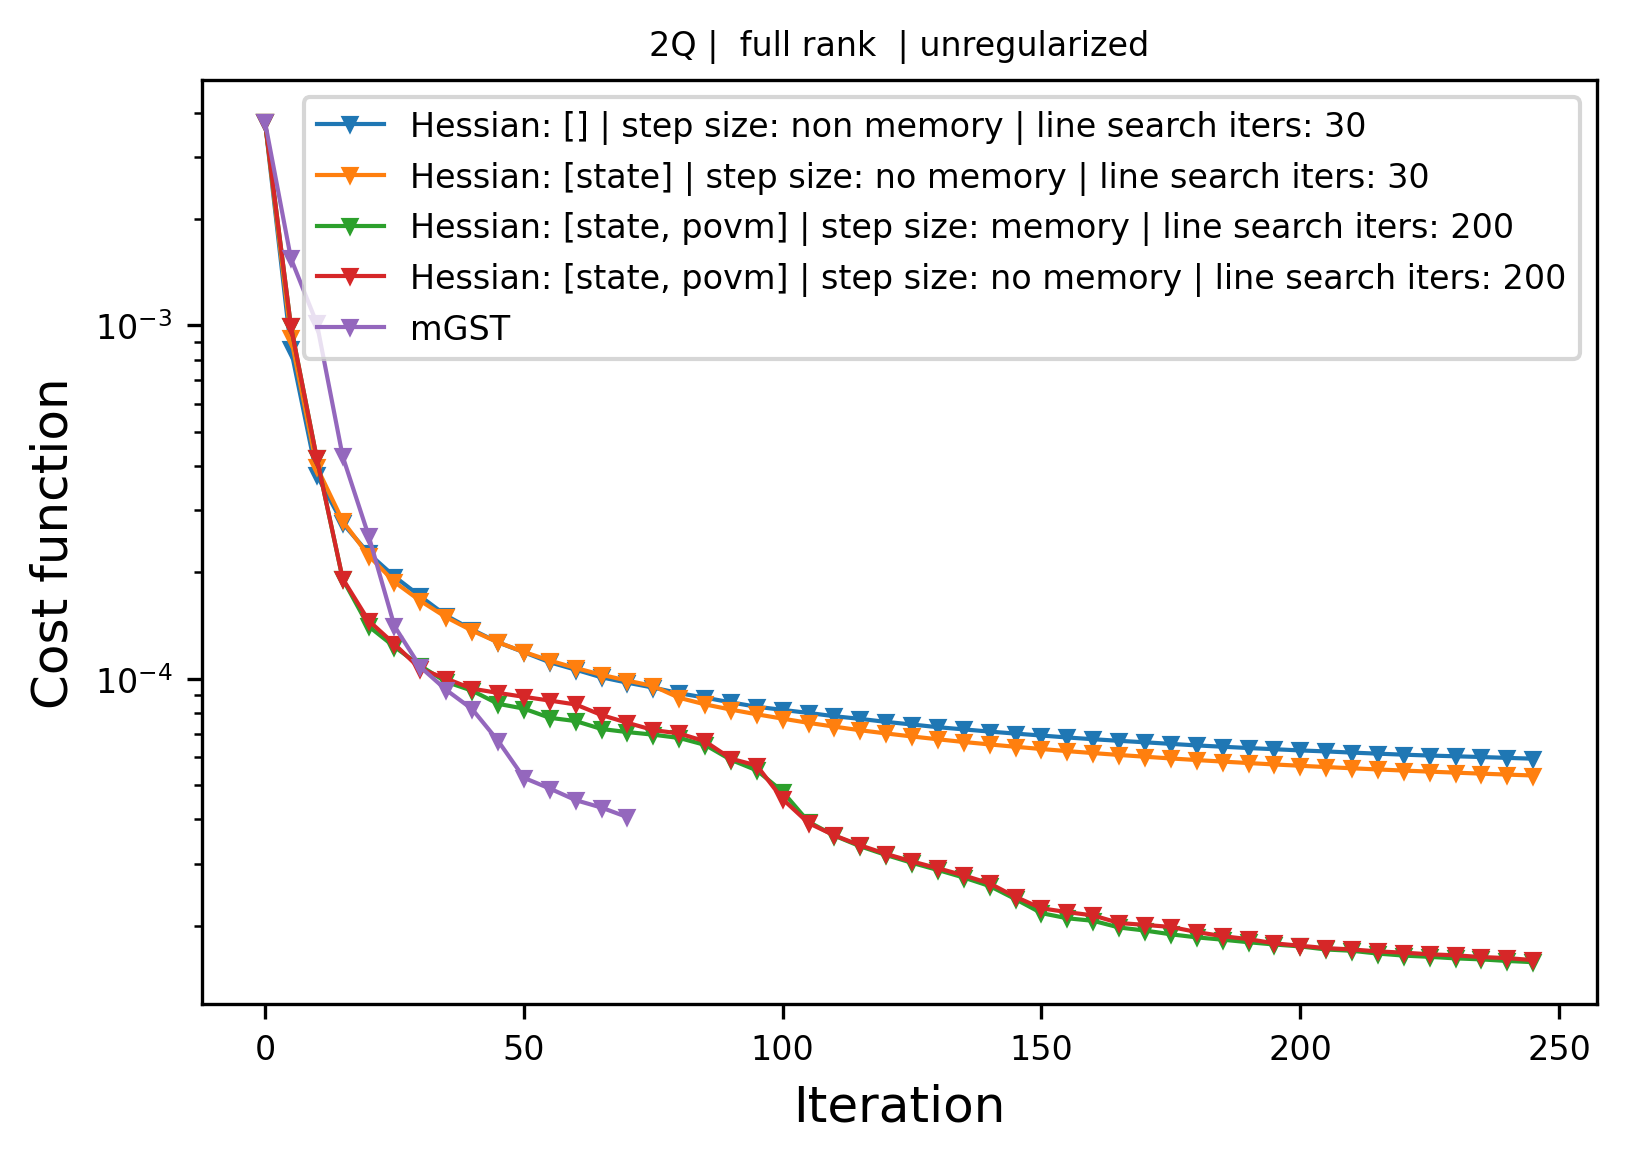

In [103]:
plot_step = 5
max_idx_data = -1

plt.figure(figsize=(6, 4), dpi=300)

plt.semilogy(range(0, len(cost_fn_history_2q_all_gds[:max_idx_data]), plot_step), cost_fn_history_2q_all_gds[:max_idx_data:plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="Hessian: [] | step size: non memory | line search iters: 30")

plt.semilogy(range(0, len(cost_fn_history_2q_unregularized_hessian_state[:max_idx_data]), plot_step), cost_fn_history_2q_unregularized_hessian_state[:max_idx_data:plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="Hessian: [state] | step size: no memory | line search iters: 30")

plt.semilogy(range(0, len(cost_fn_history_2q_unregularized_hessian_povm[:max_idx_data]), plot_step), cost_fn_history_2q_unregularized_hessian_povm[:max_idx_data:plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="Hessian: [state, povm] | step size: memory | line search iters: 200")

plt.semilogy(range(0, len(cost_fn_history_2q_unregularized_hessian_povm_no_stepsize_memory[:max_idx_data]), plot_step), cost_fn_history_2q_unregularized_hessian_povm_no_stepsize_memory[:max_idx_data:plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="Hessian: [state, povm] | step size: no memory | line search iters: 200")

plt.semilogy(range(0, len(cost_fn_history_2q_mgst), plot_step), cost_fn_history_2q_mgst[::plot_step], marker="v", linestyle="-", linewidth=1, markersize=3, label="mGST")


plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q |  full rank  | unregularized")
plt.ylabel("Cost function", fontsize=12)
plt.legend()

# Why are they not exactly the same?

Check the Hessian we are producing on one step of MGST vs one step of JAX

In [142]:
cost_fn_history_2q_mgst[:3], cost_fn_history_2q_unregularized_hessian_povm_no_stepsize_memory[:3]

([Array(0.00375904, dtype=float64),
  Array(0.0028788, dtype=float64),
  Array(0.00237684, dtype=float64)],
 [Array(0.00375904, dtype=float64),
  Array(0.00280754, dtype=float64),
  Array(0.00210924, dtype=float64)])

In [133]:
from mGST.utility_functions_comparisons import get_compressed_rep_mgst_cholesky, update_povm_via_saddle_free_newton, update_state_via_saddle_free_newton

# K_init_mgst
povm_psd_mgst, state_psd_mgst = get_compressed_rep_mgst_cholesky(E_target_mgst, rho_target_mgst)
# calculate the new povm factor
new_povm_psd_mgst = update_povm_via_saddle_free_newton(
        kraus_tensor=K_init_mgst,
        povm_psd=povm_psd_mgst,
        state_psd=state_psd_mgst,
        indices_list=indices_list_2q,
        prob_matrix=prob_matrix_2q_sampled,
    )

new_povm_psd_jax = update_povm_via_saddle_free_newton(
        kraus_tensor=kraus_tensor_2q_init,
        povm_psd=povm_psd_2q_target,
        state_psd=state_psd_2q_target,
        indices_list=indices_list_2q,
        prob_matrix=prob_matrix_2q_sampled,
    )

new_state_psd_mgst = update_state_via_saddle_free_newton(
        kraus_tensor=K_init_mgst,
        povm_psd=new_povm_psd_mgst,
        state_psd=state_psd_mgst,
        indices_list=indices_list_2q,
        prob_matrix=prob_matrix_2q_sampled,
    )

new_state_psd_jax = update_state_via_saddle_free_newton(
        kraus_tensor=kraus_tensor_2q_init,
        povm_psd=new_povm_psd_jax,
        state_psd=state_psd_2q_target,
        indices_list=indices_list_2q,
        prob_matrix=prob_matrix_2q_sampled,
    )

jnp.allclose(new_povm_psd_mgst, new_povm_psd_jax), jnp.allclose(new_state_psd_mgst, new_state_psd_jax)

(Array(False, dtype=bool), Array(False, dtype=bool))

In [141]:
# now for the kraus tensor.
from mGST.algorithm import gd
from mGST.utility_functions_comparisons import _update_tensor_via_gradient

fixed_gates = np.array([(f"G%i" % i in []) for i in range(num_gates)])
fixed_gates

new_kraus_tensor_mgst = gd(
    K_init_mgst, E_target_mgst, rho_target_mgst, prob_matrix_2q_sampled, indices_list_2q,
    d=num_gates, r=dim**2, rK=dim**2, ls="COBYLA", fixed_gates=fixed_gates
)

new_kraus_tensor_jax, _ = _update_tensor_via_gradient("kraus", kraus_tensor_2q_init, povm_psd_2q_target, state_psd_2q_target, indices_list_2q, prob_matrix_2q_sampled, ls_method="COBYLA", ls_max_iter=200, initial_step=1e-8)

Using JAX power
Optimized step size for Kraus: [7.22725079]


In [144]:
def povm_from_psd(povm_psd:jnp.ndarray) -> jnp.ndarray:
    """
    Get the full POVM tensor from its factorization
    Args:
        povm_psd: Factorization of the POVM of shape (num_povm, rank_povm, dim)
    """
    return jnp.einsum("irk, irm -> ikm", povm_psd.conj(), povm_psd)

def state_from_psd(state_psd:jnp.ndarray) -> jnp.ndarray:
    """
    Get the full state tensor from its factorization
    Args:
        state_psd: Factorization of the state of shape (dim, rank_state)
    """
    return state_psd @ state_psd.conj().T

def kraus_from_psd(kraus_psd:jnp.ndarray)->jnp.ndarray:
    """Get the full kraus tensor from its factorization

    Args:
        kraus_psd: Factorization of the kraus tensor of shape (num_gates, rank_kraus, dim_out, dim_in)

    Returns:
        Full kraus tensor of shape (num_gates, dim_out, dim_out*, dim_in, dim_in*)
    """
    # num_gates, rank_kraus, dim, dim = kraus_psd.shape
    return jnp.einsum("ijkl,ijnm -> iknlm", kraus_psd, kraus_psd.conj())

povm_test_mgst = povm_from_psd(new_povm_psd_mgst)
povm_test_jax = povm_from_psd(new_povm_psd_jax)

state_test_mgst = state_from_psd(new_state_psd_mgst)
state_test_jax = state_from_psd(new_state_psd_jax)

kraus_test_mgst = kraus_from_psd(new_kraus_tensor_mgst)
kraus_test_jax = kraus_from_psd(new_kraus_tensor_jax)

jnp.allclose(povm_test_mgst, povm_test_jax), jnp.allclose(state_test_mgst, state_test_jax), jnp.allclose(kraus_test_mgst, kraus_test_jax)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(False, dtype=bool))

In [136]:
initial_value_mgst = cost_function_jax_mps(K_init_mgst, povm_psd_mgst, state_psd_mgst, indices_list_2q, prob_matrix_2q_sampled, jit=True)
initial_value_jax = cost_function_jax_mps(kraus_tensor_2q_init, povm_psd_2q_target, state_psd_2q_target, indices_list_2q, prob_matrix_2q_sampled, jit=True)
assert jnp.allclose(initial_value_mgst, initial_value_jax)

In [137]:
updated_value_mgst = cost_function_jax_mps(K_init_mgst, new_povm_psd_mgst, new_state_psd_mgst, indices_list_2q, prob_matrix_2q_sampled, jit=True)
update_value_jax = cost_function_jax_mps(kraus_tensor_2q_init, new_povm_psd_jax, new_state_psd_jax, indices_list_2q, prob_matrix_2q_sampled, jit=True)
jnp.allclose(updated_value_mgst, update_value_jax)

Array(True, dtype=bool)